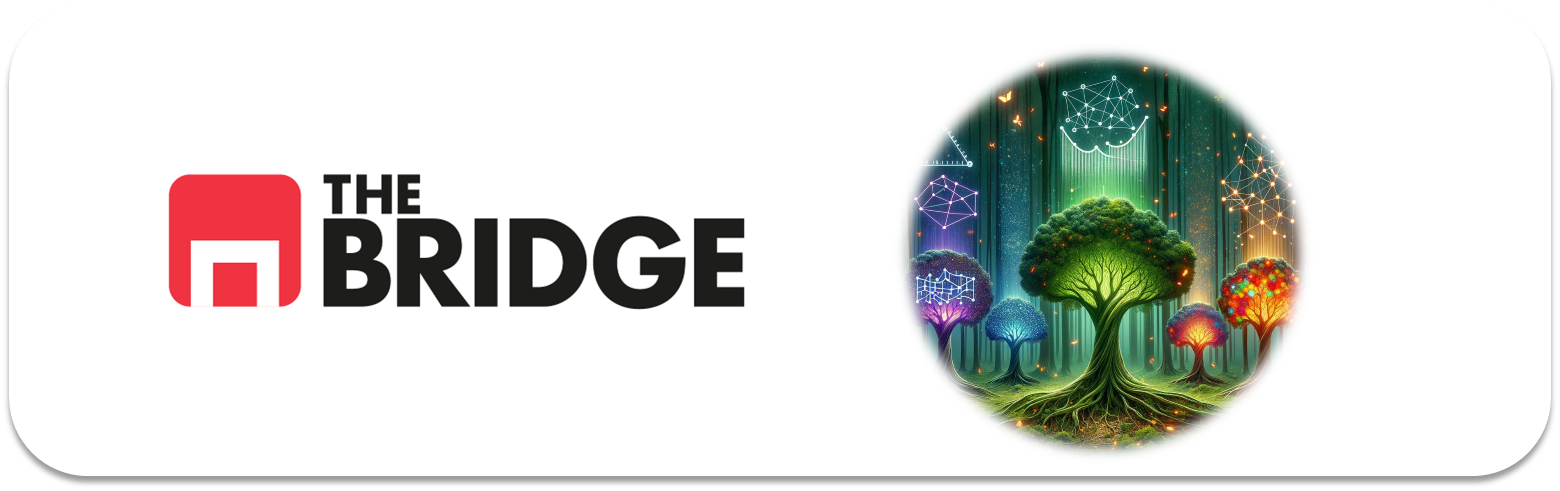

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Toolkit de visualización del bootcamp (incluido en este directorio)
import bootcampviztools as bvt

# Particionado, validación cruzada y optimización de hiperparámetros
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV,
    GridSearchCV,
)

# Preprocesado: imputación dentro de un Pipeline para evitar data leakage
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelos de ensemble
from sklearn.ensemble import (
    RandomForestClassifier,      # Bagging
    AdaBoostClassifier,          # Boosting
    GradientBoostingClassifier,  # Boosting
)
from xgboost import XGBClassifier        # Boosting
from lightgbm import LGBMClassifier      # Boosting

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    balanced_accuracy_score,
)

# Reproducibilidad
SEED = 42

# Estética de las gráficas
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

In [3]:
df = pd.read_csv(url, names=names)
df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

## Resolución

Vamos a seguir el flujo de trabajo habitual:

1. **Exploración inicial (EDA)** de las variables y del objetivo.
2. **Calidad de los datos**: detección de los ceros imposibles que en realidad codifican valores ausentes.
3. **Separación train / test**, reservando el test y *sin volver a tocarlo* hasta el final.
4. **Modelos candidatos** de *bagging* y *boosting* (al menos uno de cada).
5. **Comparación con validación cruzada** sobre el train, **sin usar el test**.
6. **Optimización de hiperparámetros** del modelo ganador.
7. **Evaluación final** del modelo optimizado contra el test reservado.

Para evitar *data leakage* en la imputación, cada modelo se envuelve en un `Pipeline`
que primero imputa y luego entrena; así la imputación se aprende en cada *fold* de la
validación cruzada usando únicamente los datos de entrenamiento de ese *fold*.

### 1. Exploración inicial de los datos (EDA)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
preg,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
plas,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
pres,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
test,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
mass,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
pedi,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
class,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Echamos un vistazo al **balance de la variable objetivo** (`class`). Es clave
porque condiciona la métrica que usaremos para comparar modelos.

In [6]:
df['class'].value_counts(normalize=True)

class
0    0.651042
1    0.348958
Name: proportion, dtype: float64

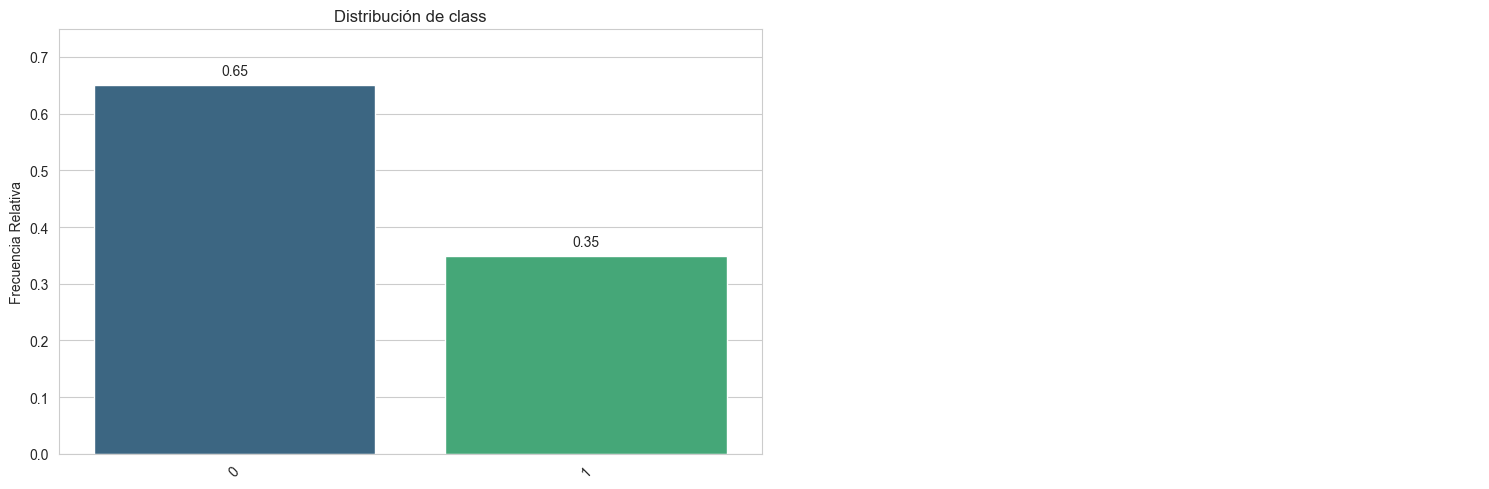

In [7]:
bvt.pinta_distribucion_categoricas(df, ['class'], relativa=True, mostrar_valores=True)

El dataset está **desbalanceado** (~65% no diabéticas / ~35% diabéticas). Por eso
no nos fiaremos solo del *accuracy*: usaremos **ROC-AUC** como métrica principal de
comparación (robusta al desbalanceo y estándar para este dataset) y reportaremos
también *balanced accuracy* y el *recall* de la clase positiva (detectar diabetes).

### 2. Calidad de los datos: ceros imposibles

En el resumen estadístico llama la atención que variables como la glucosa (`plas`),
la presión arterial (`pres`), el grosor del pliegue cutáneo (`skin`), la insulina
(`test`) o el índice de masa corporal (`mass`) tengan **mínimo 0**. Un valor de 0
en esas magnitudes es fisiológicamente imposible: en realidad son **valores ausentes
codificados como 0**.

In [8]:
# Columnas en las que un 0 no tiene sentido clínico
cols_cero_invalido = ['plas', 'pres', 'skin', 'test', 'mass']

# ¿Cuántos ceros (= ausentes encubiertos) hay en cada una?
(df[cols_cero_invalido] == 0).sum()

plas      5
pres     35
skin    227
test    374
mass     11
dtype: int64

`skin` (pliegue cutáneo) e `test` (insulina) son los más afectados. Sustituimos esos
ceros por `NaN` para tratarlos como lo que son: valores ausentes que después
imputaremos dentro del `Pipeline`.

In [9]:
df_clean = df.copy()
df_clean[cols_cero_invalido] = df_clean[cols_cero_invalido].replace(0, np.nan)

print("Valores ausentes tras marcar los ceros imposibles:")
df_clean.isna().sum()

Valores ausentes tras marcar los ceros imposibles:


preg       0
plas       5
pres      35
skin     227
test     374
mass      11
pedi       0
age        0
class      0
dtype: int64

Distribución de las variables numéricas (histograma + KDE y boxplot) con el toolkit del bootcamp:

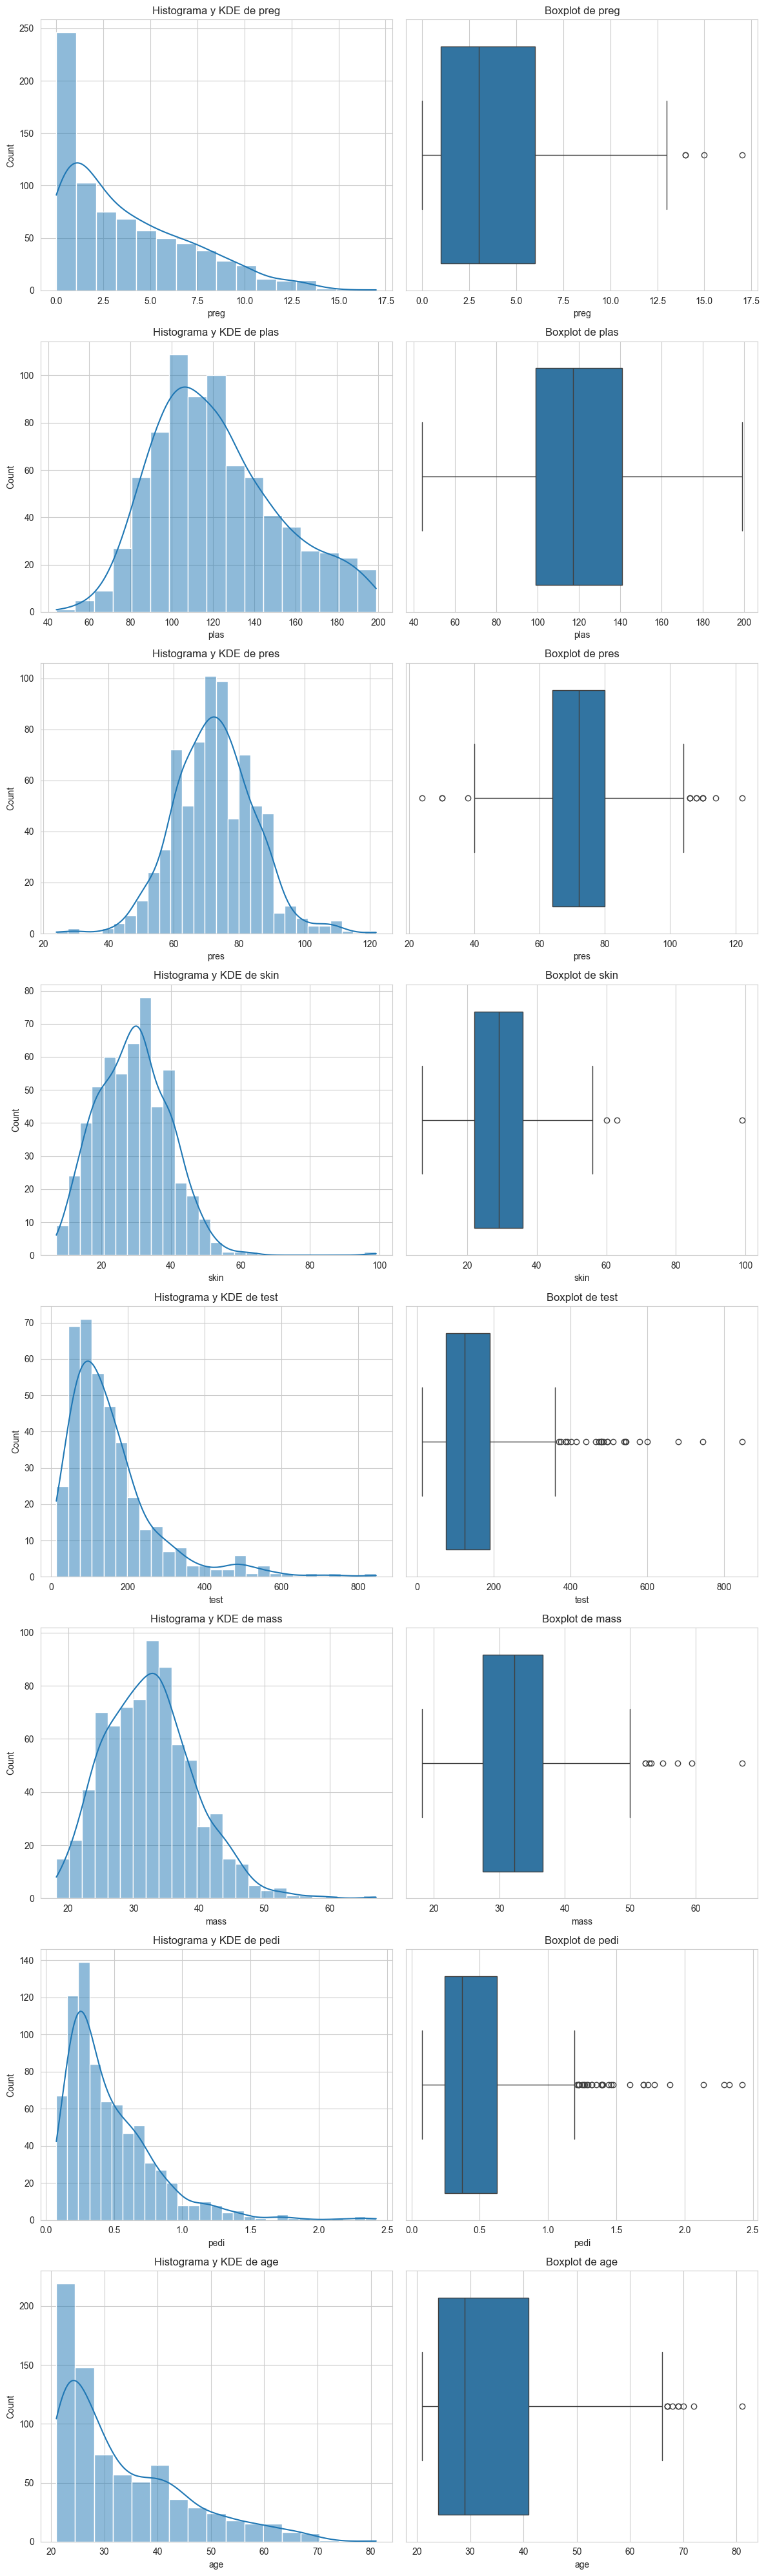

In [10]:
features = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
bvt.plot_combined_graphs(df_clean, features)

Comparamos la distribución de las variables más relevantes **según la clase** para
intuir su poder predictivo. Se ve claramente que las diabéticas tienden a tener mayor
glucosa (`plas`), mayor IMC (`mass`) y mayor edad (`age`).

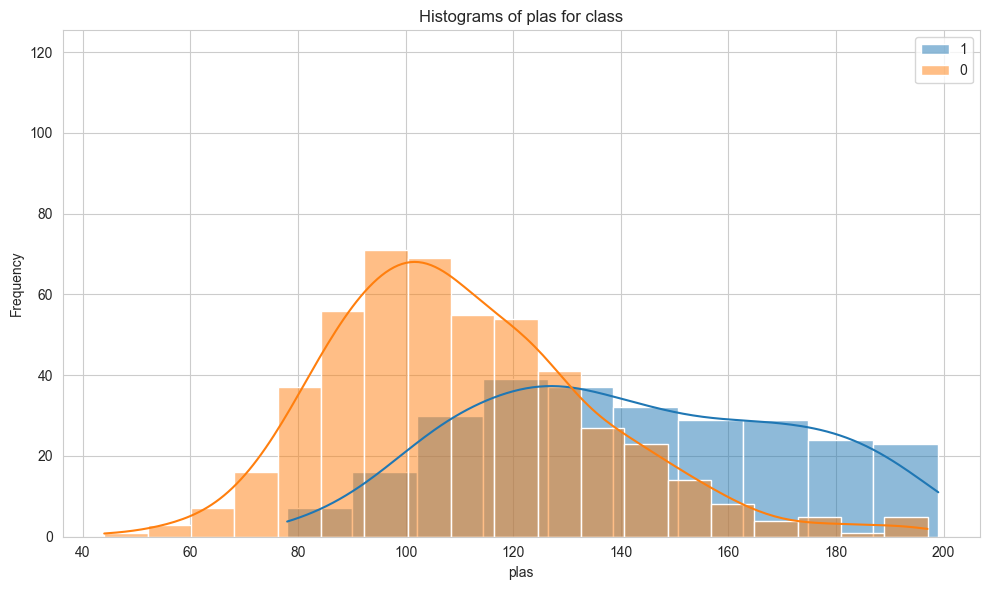

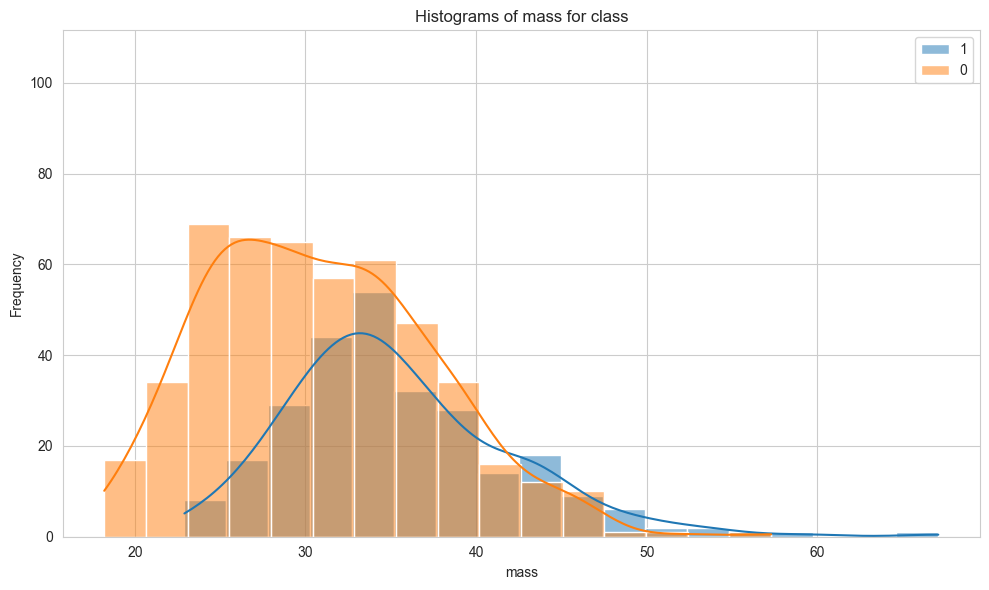

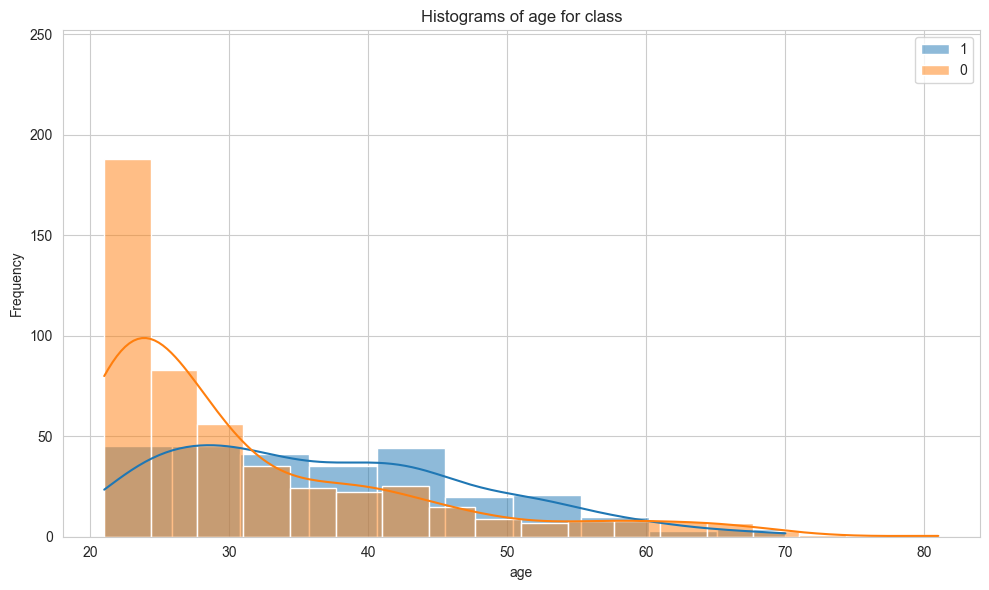

In [11]:
for col in ['plas', 'mass', 'age']:
    bvt.plot_grouped_histograms(df_clean, cat_col='class', num_col=col, group_size=2)

Matriz de correlación entre las variables:

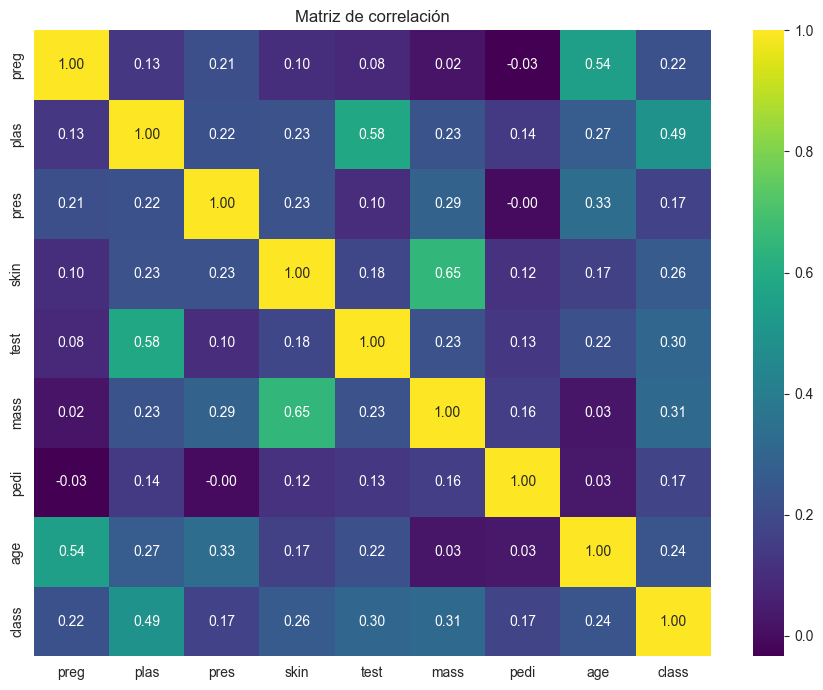

In [12]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='viridis')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

`plas` es la variable más correlacionada con el objetivo, seguida de `mass`, `age` y
`preg`. No hay correlaciones extremas entre predictores que obliguen a eliminar
variables, así que las mantenemos todas (los modelos de árboles toleran bien la
multicolinealidad).

### 3. Separación train / test (reservamos el test)

Separamos **antes de cualquier ajuste** un 20% de test estratificado por la clase.
Este conjunto queda *congelado*: no se usa ni para explorar, ni para comparar, ni
para optimizar. Solo se toca en el paso 7 para la evaluación final.

In [13]:
X = df_clean.drop(columns='class')
y = df_clean['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # mantiene la proporción de clases en train y test
    random_state=SEED,
)

print(f"Train: {X_train.shape[0]} instancias | Test: {X_test.shape[0]} instancias")
print("\nProporción de clases en train:")
print(y_train.value_counts(normalize=True).round(3).to_string())
print("\nProporción de clases en test:")
print(y_test.value_counts(normalize=True).round(3).to_string())

Train: 614 instancias | Test: 154 instancias

Proporción de clases en train:
class
0    0.651
1    0.349

Proporción de clases en test:
class
0    0.649
1    0.351


> **Nota sobre la imputación.** No imputamos aquí de forma global porque eso filtraría
> información del conjunto completo a cada *fold*. En su lugar, la imputación
> (`SimpleImputer(strategy='median')`) va **dentro de cada Pipeline**, de modo que la
> validación cruzada y el `GridSearch` la reaprenden en cada partición sin *leakage*.

### 4. Modelos candidatos (bagging y boosting)

Definimos cinco candidatos, **uno de bagging y cuatro de boosting**, cubriendo de
sobra el mínimo exigido (al menos tres modelos, al menos uno de cada familia):

| Modelo | Familia |
|--------|---------|
| `RandomForestClassifier` | **Bagging** |
| `AdaBoostClassifier` | **Boosting** |
| `GradientBoostingClassifier` | **Boosting** |
| `XGBClassifier` | **Boosting** |
| `LGBMClassifier` | **Boosting** |

Cada modelo se envuelve en un `Pipeline` con la imputación por mediana.

In [14]:
def make_pipe(model):
    """Envuelve un modelo con imputación por mediana para evitar data leakage."""
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', model),
    ])

modelos = {
    'RandomForest':     make_pipe(RandomForestClassifier(random_state=SEED)),
    'AdaBoost':         make_pipe(AdaBoostClassifier(random_state=SEED)),
    'GradientBoosting': make_pipe(GradientBoostingClassifier(random_state=SEED)),
    'XGBoost':          make_pipe(XGBClassifier(random_state=SEED, eval_metric='logloss')),
    'LightGBM':         make_pipe(LGBMClassifier(random_state=SEED, verbose=-1)),
}

familia = {
    'RandomForest': 'Bagging',
    'AdaBoost': 'Boosting',
    'GradientBoosting': 'Boosting',
    'XGBoost': 'Boosting',
    'LightGBM': 'Boosting',
}
list(modelos.keys())

['RandomForest', 'AdaBoost', 'GradientBoosting', 'XGBoost', 'LightGBM']

### 5. Comparación mediante validación cruzada (sin tocar el test)

Comparamos los cinco modelos con **validación cruzada estratificada de 5 folds**
sobre el conjunto de **train**. La métrica principal es **ROC-AUC**; además guardamos
*accuracy* y *balanced accuracy* como apoyo. En ningún momento usamos el test.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados = []
for nombre, pipe in modelos.items():
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    bacc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='balanced_accuracy')
    resultados.append({
        'Modelo': nombre,
        'Familia': familia[nombre],
        'ROC_AUC_mean': auc.mean(),
        'ROC_AUC_std': auc.std(),
        'Accuracy_mean': acc.mean(),
        'Balanced_Acc_mean': bacc.mean(),
    })
    print(f"{nombre:18s} | ROC-AUC: {auc.mean():.4f} (+/- {auc.std():.4f})"
          f" | Acc: {acc.mean():.4f} | Bal.Acc: {bacc.mean():.4f}")

resultados_df = pd.DataFrame(resultados).sort_values('ROC_AUC_mean', ascending=False).reset_index(drop=True)
resultados_df

RandomForest       | ROC-AUC: 0.8163 (+/- 0.0220) | Acc: 0.7606 | Bal.Acc: 0.7175


AdaBoost           | ROC-AUC: 0.8184 (+/- 0.0171) | Acc: 0.7655 | Bal.Acc: 0.7202


GradientBoosting   | ROC-AUC: 0.8195 (+/- 0.0162) | Acc: 0.7541 | Bal.Acc: 0.7178


XGBoost            | ROC-AUC: 0.7787 (+/- 0.0260) | Acc: 0.7329 | Bal.Acc: 0.6995


C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMCl

...

C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM           | ROC-AUC: 0.7975 (+/- 0.0321) | Acc: 0.7427 | Bal.Acc: 0.7048


C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Modelo,Familia,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Balanced_Acc_mean
0,GradientBoosting,Boosting,0.819453,0.016180,0.754058,0.717809
1,AdaBoost,Boosting,0.818443,0.017075,0.765480,0.720161
2,RandomForest,Bagging,0.816286,0.021958,0.760602,0.717486
3,LightGBM,Boosting,0.797506,0.032070,0.742690,0.704812
4,XGBoost,Boosting,0.778682,0.026017,0.732907,0.699463


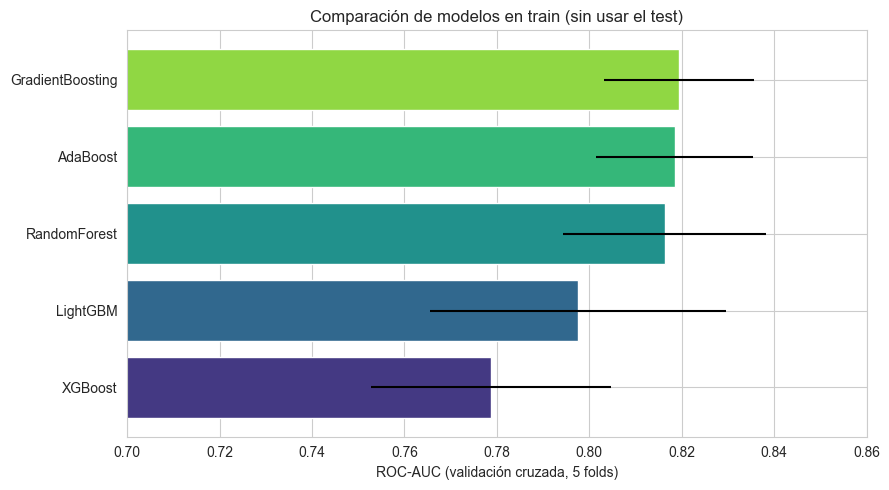

In [16]:
plt.figure(figsize=(9, 5))
orden = resultados_df.sort_values('ROC_AUC_mean')
plt.barh(orden['Modelo'], orden['ROC_AUC_mean'],
         xerr=orden['ROC_AUC_std'], color=sns.color_palette('viridis', len(orden)))
plt.xlabel('ROC-AUC (validación cruzada, 5 folds)')
plt.title('Comparación de modelos en train (sin usar el test)')
plt.xlim(0.7, max(0.86, orden['ROC_AUC_mean'].max() + 0.03))
plt.tight_layout()
plt.show()

In [17]:
ganador = resultados_df.iloc[0]['Modelo']
print(f"Modelo ganador segun ROC-AUC en validacion cruzada: {ganador}")

Modelo ganador segun ROC-AUC en validacion cruzada: GradientBoosting


**Selección y justificación.** Elegimos el modelo con mejor **ROC-AUC medio** en la
validación cruzada (celda anterior). Es la elección razonable porque:

- La métrica se ha medido **solo sobre el train**, con validación cruzada estratificada,
  sin contaminar el test.
- **ROC-AUC** es adecuada para un problema **desbalanceado** como este, ya que valora
  la capacidad de discriminación del modelo con independencia del umbral de decisión.
- Además de tener la media más alta, conviene que su desviación entre *folds* sea
  contenida (modelo estable).

A continuación optimizamos los hiperparámetros de ese ganador.

### 6. Optimización de hiperparámetros del modelo ganador

Definimos una rejilla de hiperparámetros por cada tipo de modelo (con el prefijo
`model__` porque van dentro del `Pipeline`) y optimizamos **el ganador** con
`RandomizedSearchCV`, manteniendo la misma validación cruzada estratificada y la
métrica ROC-AUC. Seguimos sin tocar el test.

In [18]:
# Rejillas por modelo (prefijo 'model__' por estar dentro del Pipeline)
param_grids = {
    'RandomForest': {
        'model__n_estimators': [100, 200, 400],
        'model__max_depth': [3, 5, 8, None],
        'model__max_features': ['sqrt', 'log2', None],
        'model__min_samples_leaf': [1, 5, 10, 20],
        'model__class_weight': ['balanced', None],
    },
    'AdaBoost': {
        'model__n_estimators': [50, 100, 200, 400],
        'model__learning_rate': [0.01, 0.1, 0.5, 1.0],
    },
    'GradientBoosting': {
        'model__n_estimators': [100, 200, 400],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__max_depth': [2, 3, 4],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__min_samples_leaf': [1, 5, 10, 20],
    },
    'XGBoost': {
        'model__n_estimators': [100, 250, 500],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__max_depth': [3, 4, 6],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
    },
    'LightGBM': {
        'model__n_estimators': [100, 250, 500],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 8, -1],
        'model__num_leaves': [15, 31, 63],
        'model__subsample': [0.6, 0.8, 1.0],
    },
}

search = RandomizedSearchCV(
    estimator=modelos[ganador],
    param_distributions=param_grids[ganador],
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=SEED,
)
search.fit(X_train, y_train)

print(f"Modelo optimizado: {ganador}")
print(f"Mejor ROC-AUC (CV): {search.best_score_:.4f}")
print("Mejores hiperparametros:")
for k, v in search.best_params_.items():
    print(f"  {k} = {v}")

Modelo optimizado: GradientBoosting
Mejor ROC-AUC (CV): 0.8354
Mejores hiperparametros:
  model__subsample = 0.6
  model__n_estimators = 200
  model__min_samples_leaf = 20
  model__max_depth = 2
  model__learning_rate = 0.01


In [19]:
# ¿Mejora respecto a la versión por defecto?
auc_default = resultados_df.set_index('Modelo').loc[ganador, 'ROC_AUC_mean']
print(f"ROC-AUC por defecto (CV): {auc_default:.4f}")
print(f"ROC-AUC optimizado (CV): {search.best_score_:.4f}")
print(f"Mejora: {search.best_score_ - auc_default:+.4f}")

best_model = search.best_estimator_

ROC-AUC por defecto (CV): 0.8195
ROC-AUC optimizado (CV): 0.8354
Mejora: +0.0160


### 7. Evaluación final sobre el test reservado

Llegó el momento de usar **por primera y única vez** el test. Evaluamos el modelo
ganador ya optimizado (entrenado con todo el train) sobre el test que reservamos
en el paso 3.

In [20]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"=== Evaluación final en TEST — {ganador} optimizado ===\n")
print(classification_report(y_test, y_pred, target_names=['No diabetes', 'Diabetes']))
print(f"ROC-AUC          : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")

=== Evaluación final en TEST — GradientBoosting optimizado ===

              precision    recall  f1-score   support

 No diabetes       0.76      0.87      0.81       100
    Diabetes       0.67      0.48      0.56        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.68       154
weighted avg       0.73      0.73      0.72       154

ROC-AUC          : 0.8098
Balanced accuracy: 0.6757


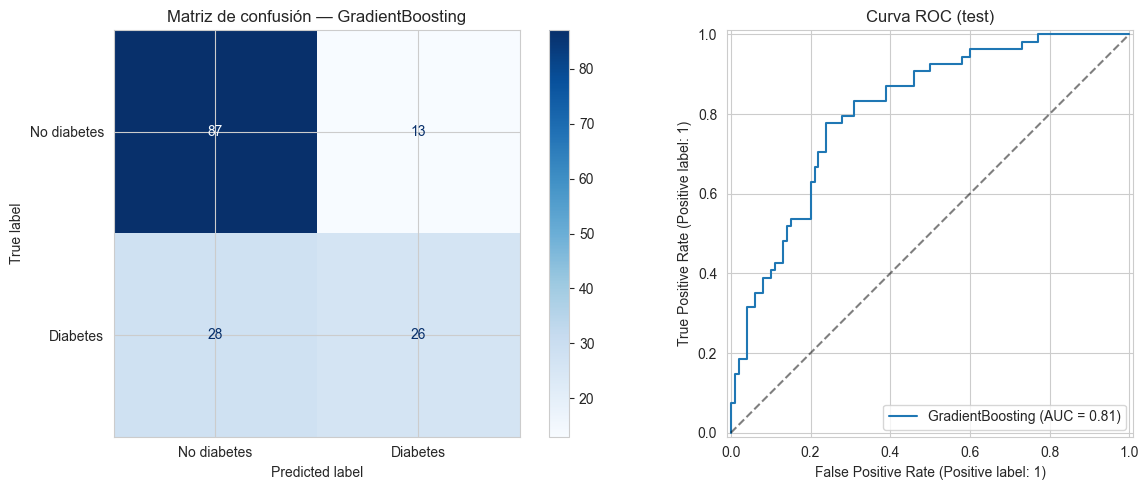

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No diabetes', 'Diabetes'], cmap='Blues', ax=axes[0])
axes[0].set_title(f'Matriz de confusión — {ganador}')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=ganador)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('Curva ROC (test)')

plt.tight_layout()
plt.show()

**Importancia de las características** según el modelo final:

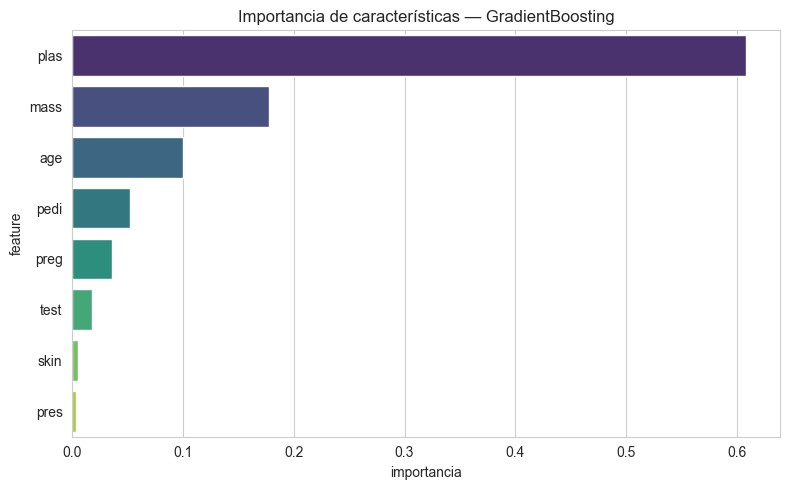

,feature,importancia
1,plas,0.608647
5,mass,0.177323
7,age,0.100115
6,pedi,0.051937
0,preg,0.035918
4,test,0.017800
3,skin,0.005324
2,pres,0.002936


In [22]:
importancias = best_model.named_steps['model'].feature_importances_
imp_df = (pd.DataFrame({'feature': X_train.columns, 'importancia': importancias})
          .sort_values('importancia', ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_df, x='importancia', y='feature', hue='feature',
            palette='viridis', legend=False)
plt.title(f'Importancia de características — {ganador}')
plt.tight_layout()
plt.show()

imp_df

### 7.1 Ajuste del umbral de decisión: el recall de la clase "Diabetes"

El classification report anterior deja un dato incómodo: con el umbral por defecto
(0.5), el **recall de la clase Diabetes es de solo 0.48** — el modelo deja escapar a
más de la mitad de las diabéticas del test. En un problema de cribado médico los
**falsos negativos son el error caro** (una paciente diabética sin detectar), mucho
más que los falsos positivos (una prueba adicional innecesaria).

Un buen ROC-AUC (0.81) nos dice que el modelo **discrimina bien**: el problema no es
el modelo sino el **umbral de decisión**. `predict()` corta en 0.5 por defecto, pero
nada nos obliga a usar ese valor.

Para elegir un umbral mejor **sin contaminar el test**, usamos las probabilidades
estimadas por validación cruzada sobre el **train** (`cross_val_predict`), y sobre
ellas buscamos el umbral que maximiza la *balanced accuracy*. Solo después aplicamos
ese umbral, ya fijado, al test.

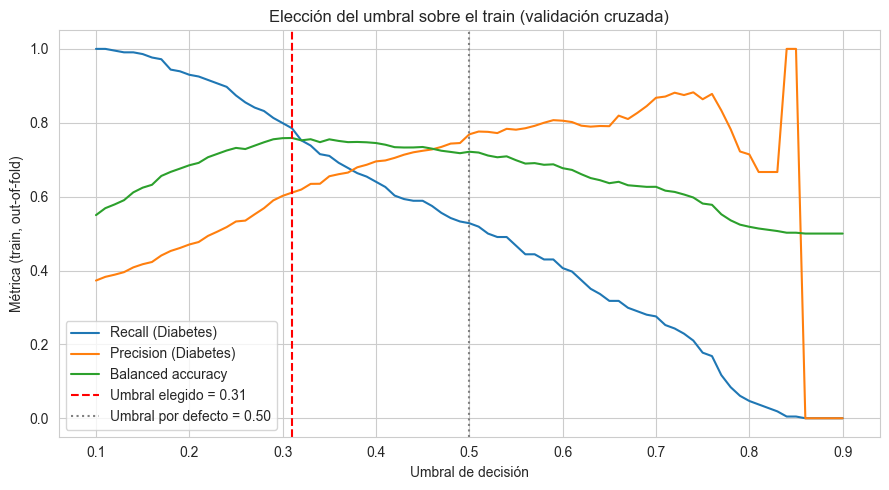

Umbral elegido en train (max balanced accuracy): 0.31


In [23]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score, precision_score

# Probabilidades out-of-fold sobre el TRAIN (cada predicción la hace un modelo
# que no vio esa instancia en su entrenamiento) -> sin tocar el test
proba_oof = cross_val_predict(best_model, X_train, y_train,
                              cv=cv, method='predict_proba')[:, 1]

# Barrido de umbrales sobre el train
umbrales = np.arange(0.10, 0.91, 0.01)
metricas_umbral = pd.DataFrame({
    'umbral': umbrales,
    'recall_diabetes': [recall_score(y_train, proba_oof >= u) for u in umbrales],
    'precision_diabetes': [precision_score(y_train, proba_oof >= u, zero_division=0) for u in umbrales],
    'balanced_accuracy': [balanced_accuracy_score(y_train, proba_oof >= u) for u in umbrales],
})

# Umbral que maximiza la balanced accuracy en train (out-of-fold)
umbral_optimo = metricas_umbral.loc[metricas_umbral['balanced_accuracy'].idxmax(), 'umbral']

plt.figure(figsize=(9, 5))
plt.plot(metricas_umbral['umbral'], metricas_umbral['recall_diabetes'], label='Recall (Diabetes)')
plt.plot(metricas_umbral['umbral'], metricas_umbral['precision_diabetes'], label='Precision (Diabetes)')
plt.plot(metricas_umbral['umbral'], metricas_umbral['balanced_accuracy'], label='Balanced accuracy')
plt.axvline(umbral_optimo, color='red', linestyle='--',
            label=f'Umbral elegido = {umbral_optimo:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Umbral por defecto = 0.50')
plt.xlabel('Umbral de decisión')
plt.ylabel('Métrica (train, out-of-fold)')
plt.title('Elección del umbral sobre el train (validación cruzada)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Umbral elegido en train (max balanced accuracy): {umbral_optimo:.2f}")

=== TEST con umbral por defecto (0.50) ===
  Recall Diabetes  : 0.481
  Balanced accuracy: 0.676

=== TEST con umbral ajustado (0.31) ===
              precision    recall  f1-score   support

 No diabetes       0.86      0.69      0.77       100
    Diabetes       0.58      0.80      0.67        54

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.76      0.73      0.73       154

  Balanced accuracy: 0.743


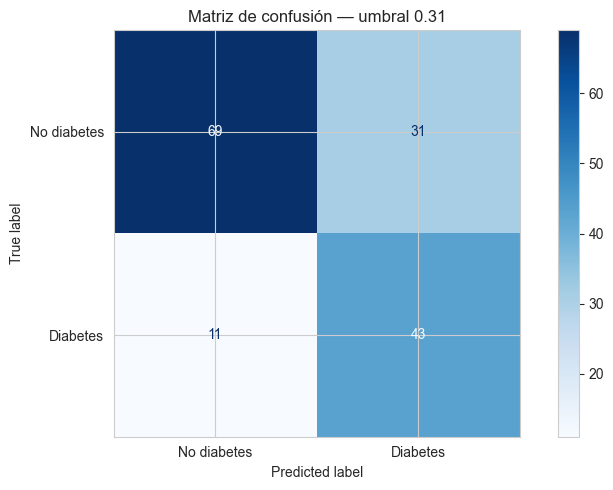

In [24]:
# Aplicamos el umbral (fijado en train) al test y comparamos con el umbral por defecto
y_pred_umbral = (y_proba >= umbral_optimo).astype(int)

print(f"=== TEST con umbral por defecto (0.50) ===")
print(f"  Recall Diabetes  : {recall_score(y_test, y_pred):.3f}")
print(f"  Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}\n")

print(f"=== TEST con umbral ajustado ({umbral_optimo:.2f}) ===")
print(classification_report(y_test, y_pred_umbral, target_names=['No diabetes', 'Diabetes']))
print(f"  Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_umbral):.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_umbral, display_labels=['No diabetes', 'Diabetes'], cmap='Blues')
plt.title(f'Matriz de confusión — umbral {umbral_optimo:.2f}')
plt.tight_layout()
plt.show()

**Lectura del ajuste de umbral.** Bajando el umbral de 0.50 a **0.31** (elegido
exclusivamente con datos de train, *out-of-fold*):

- El **recall de Diabetes sube de 0.48 a 0.80**: pasamos de detectar 26 de las 54
  diabéticas del test a detectar 43.
- La **balanced accuracy mejora de 0.68 a 0.74** y el accuracy global se mantiene (0.73).
- El precio es la **precisión de la clase Diabetes** (0.67 → 0.58): más falsos
  positivos, es decir, más mujeres sanas señaladas para una prueba de confirmación.

En un contexto de cribado este intercambio es claramente favorable: el coste de un
falso negativo (diabetes sin detectar) supera al de un falso positivo (una prueba
extra). El modelo es el mismo — solo hemos movido el punto de corte sobre las
probabilidades, algo que el ROC-AUC ya anticipaba que era posible.

### 8. Conclusiones

- **Preparación de datos.** Detectamos que los ceros en `plas`, `pres`, `skin`, `test`
  y `mass` eran en realidad **valores ausentes** y los imputamos por la mediana
  **dentro de un `Pipeline`**, evitando *data leakage* en la validación cruzada.

- **Comparación honesta.** Comparamos cinco modelos de *ensemble* (uno de **bagging**
  — Random Forest — y cuatro de **boosting** — AdaBoost, Gradient Boosting, XGBoost y
  LightGBM) mediante **validación cruzada estratificada** sobre el train, usando
  **ROC-AUC** como métrica principal por el desbalanceo de clases, **sin tocar el test**.

- **Selección.** Se eligió como mejor modelo el de mayor ROC-AUC en validación cruzada
  (**Gradient Boosting**) y se **optimizaron sus hiperparámetros** con
  `RandomizedSearchCV` (ROC-AUC en CV: 0.8195 → 0.8354). Los hiperparámetros ganadores
  son muy conservadores (árboles de profundidad 2, learning rate 0.01), lo esperable
  con solo 614 instancias de entrenamiento.

- **Evaluación final.** Solo entonces se evaluó el modelo optimizado contra el **test
  reservado**. El **ROC-AUC de test (0.810)** es coherente con el de validación cruzada
  (0.835): la pequeña caída es el optimismo habitual de toda búsqueda de hiperparámetros,
  no un sobreajuste preocupante. La **balanced accuracy**, en cambio, sí bajó más
  (0.72 en CV → 0.68 en test) y el **recall de la clase Diabetes con el umbral por
  defecto era de solo 0.48** — la capacidad de discriminación era buena, pero el punto
  de corte no.

- **Ajuste del umbral.** Por eso, como paso final, elegimos el **umbral de decisión
  (0.31)** sobre el train con probabilidades *out-of-fold*. Aplicado al test, el recall
  de Diabetes sube de **0.48 a 0.80** y la balanced accuracy de **0.68 a 0.74**, a
  cambio de algo de precisión (0.67 → 0.58): un intercambio favorable en un problema
  de cribado médico, donde el falso negativo es el error caro.

- **Interpretabilidad.** La variable **glucosa (`plas`)** resulta, como cabía esperar,
  la más importante para predecir la diabetes, seguida del IMC, la edad y la función
  de pedigrí.

Este flujo (EDA → limpieza → split con test reservado → comparación por CV → optimización
→ evaluación final → ajuste del umbral a los costes del problema) es la forma
metodológicamente correcta de seleccionar, validar y poner a punto un modelo de
clasificación: el modelo no termina en `predict()`.